# NHTSA complaints - a multi-label component classifier, and the trend it publishes

**Arkon Manufacturing AI | Module: NLP Text Classification | Department: Field Quality**

Notebooks 01 and 02 established what the file holds and reduced it to 215,730
complaints, 24 component classes and three contiguous time windows. This notebook
fits the module and decides what it publishes.

Two things here are new to this project and each gets its own half of the notebook.

**The input is what a member of the public wrote.** Every other Arkon module measures
a physical thing: a sensor trace, a service record, a photograph of a part. This one
reads a report about a vehicle written by its owner, in capitals, often unpunctuated,
sometimes transcribed by a clerk to a template. The module can say what a text is
about. It cannot say whether the vehicle actually has that fault, and nothing in this
notebook attempts to.

**The event is not about the complaint.** 60,039 held-out complaints would be 60,039
events, which is four times what the whole incident store has ever held and would bury
it the way Scania's 15,222 P4 events would have. What a field-quality function acts on
is not one report, it is a rate that moved. So the classifier feeds a trend detector,
and the trend detector is what publishes the section 6 contract.

In [1]:
import sys
from pathlib import Path

_nb_root = Path('../..').resolve()
if str(_nb_root) not in sys.path:
    sys.path.insert(0, str(_nb_root))

from utils.arkon_utils import get_mlflow_uri, save_figure

print('arkon_utils loaded')

arkon_utils loaded


## 1. Imports and configuration

In [2]:
import json
import platform
import time
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.stats import poisson
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer

REPO_ROOT = Path('../../..').resolve()
PROCESSED = REPO_ROOT / 'data' / '07_nhtsa_complaints' / 'processed'
CKPT = REPO_ROOT / 'models' / 'checkpoints' / 'nhtsa'
CKPT.mkdir(parents=True, exist_ok=True)

SEED = 42
MODEL_VERSION = 'nhtsa_tfidf_ovr_v1'
EXPERIMENT_NAME = 'arkon_nhtsa_nlp'

# Every rule below is declared here, before any curve is drawn. Three of them can
# fail to return an answer, and what happens then is declared too.
TARGET_PRECISION = 0.60        # the per-class threshold rule, same target as GC10
FAMILY_ALPHA = 0.01            # trend gate, before the multiple-testing correction
MIN_EXPECTED = 3.0             # a cell with less history than this is not tested
MIN_BASELINE_MONTHS = 3        # months of trailing history a cell needs
BASELINE_MONTHS = 6            # length of the trailing baseline window
TARGET_AGREEMENT = 0.80        # the band edge rule
MIN_CALIBRATION_CELLS = 30     # below this the band rule has no sample to answer from
FALLBACK_BAND_EDGE = 0.75      # used, and labelled, if the rule returns nothing

np.random.seed(SEED)
pd.set_option('display.width', 175)
pd.set_option('display.max_columns', 40)
print(f'seed {SEED}, model version {MODEL_VERSION}')

seed 42, model version nhtsa_tfidf_ovr_v1


## 2. The data, and the label matrix

In [3]:
df = pd.read_parquet(PROCESSED / 'nhtsa_complaints.parquet')
space = json.loads((PROCESSED / 'nhtsa_label_space.json').read_text(encoding='utf-8'))
df['label_list'] = df['labels'].str.split('|')

CLASSES = space['classes']
parts = {name: df[df['split'] == name].reset_index(drop=True) for name in
         ['train', 'selection', 'test']}
for name, part in parts.items():
    print(f'{name:<10}{len(part):>9,}  {part["datea"].min()} to {part["datea"].max()}')

mlb = MultiLabelBinarizer(classes=CLASSES)
mlb.fit(parts['train']['label_list'])
Y = {name: mlb.transform(parts[name]['label_list'])
     for name in ['train', 'selection', 'test']}
print(f'\n{len(CLASSES)} classes, label matrix {Y["train"].shape}')
print(f'label instances: ' + ', '.join(f'{n}={int(Y[n].sum()):,}' for n in Y))

# The split is the whole basis of the evaluation, so it is re-asserted here rather
# than trusted from the notebook that built it.
for a, b in (('train', 'test'), ('selection', 'test'), ('train', 'selection')):
    overlap = set(parts[a]['narrative']) & set(parts[b]['narrative'])
    print(f'narratives shared by {a} and {b}: {len(overlap)}')
    assert not overlap

train       126,154  20201104 to 20230630
selection    29,537  20230701 to 20231231
test         60,039  20240101 to 20241231

24 classes, label matrix (126154, 24)
label instances: train=170,803, selection=40,540, test=81,846
narratives shared by train and test: 0


narratives shared by selection and test: 0
narratives shared by train and selection: 0


## 3. Features

TF-IDF over word unigrams and bigrams. The environment has neither `transformers` nor
`spacy` nor `nltk`, and adding one for this module would be a dependency added for a
single number, which this project's conventions ask to be flagged rather than done
quietly. A linear model over TF-IDF is also the approach whose failures are legible:
every prediction traces back to words that are in the text.

In [4]:
t0 = time.time()
vectoriser = TfidfVectorizer(sublinear_tf=True, min_df=5, ngram_range=(1, 2),
                             strip_accents='unicode', lowercase=True)
X = {'train': vectoriser.fit_transform(parts['train']['narrative'])}
X['selection'] = vectoriser.transform(parts['selection']['narrative'])
X['test'] = vectoriser.transform(parts['test']['narrative'])

print(f'vocabulary : {len(vectoriser.vocabulary_):,} terms')
print(f'train matrix: {X["train"].shape}, {X["train"].nnz:,} non-zeros, '
      f'{X["train"].nnz / X["train"].shape[0]:.1f} per complaint')
print(f'built in {time.time() - t0:.1f}s')

vocabulary : 202,240 terms
train matrix: (126154, 202240), 17,561,163 non-zeros, 139.2 per complaint
built in 37.9s


In [5]:
# What the vocabulary is made of, which is a check that the text is what it looks like.
terms = np.array(vectoriser.get_feature_names_out())
bigram = np.char.count(terms.astype(str), ' ') == 1
print(f'unigrams: {int((~bigram).sum()):,}   bigrams: {int(bigram.sum()):,}')
freq = np.asarray(X['train'].sum(axis=0)).ravel()
top = np.argsort(-freq)[:18]
print('highest total weight: ' + ', '.join(terms[i] for i in top))

unigrams: 18,225   bigrams: 184,015
highest total weight: the, to, was, and, the contact, contact, vehicle, of, not, the vehicle, it, on, that, failure, in, is, car, this


## 4. Two reference points before the model

A score means nothing without something to compare it to, and the comparison has to be
something a person could have done without the model.

In [6]:
def multilabel_report(y_true, y_pred, name):
    """Micro and macro F1, plus the two subset measures that bracket them."""
    exact = float((y_true == y_pred).all(axis=1).mean())
    any_hit = float(((y_true & y_pred).sum(axis=1) > 0)[y_true.sum(axis=1) > 0].mean())
    return {
        'arm': name,
        'micro_f1': float(f1_score(y_true, y_pred, average='micro', zero_division=0)),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'micro_precision': float(precision_score(y_true, y_pred, average='micro', zero_division=0)),
        'micro_recall': float(recall_score(y_true, y_pred, average='micro', zero_division=0)),
        'exact_set': exact,
        'any_label_hit': any_hit,
    }


# Reference 1: always answer with the single most common class in the training window.
prior = Y['train'].sum(axis=0)
most_common = int(np.argmax(prior))
const_pred = np.zeros_like(Y['test'])
const_pred[:, most_common] = 1
baseline_const = multilabel_report(Y['test'], const_pred,
                                  f'always "{CLASSES[most_common]}"')

# Reference 2: answer with every class whose training prevalence is above one half,
# which is the best a model that ignores the text can do under a 0.5 rule.
always = (prior / len(Y['train'])) >= 0.5
baseline_prior = multilabel_report(Y['test'], np.tile(always.astype(int), (len(Y['test']), 1)),
                                   'prevalence only, no text')
print(pd.DataFrame([baseline_const, baseline_prior]).round(4).to_string(index=False))

                     arm  micro_f1  macro_f1  micro_precision  micro_recall  exact_set  any_label_hit
         always "ENGINE"    0.1982    0.0158           0.2342        0.1718       0.13         0.2342
prevalence only, no text    0.0000    0.0000           0.0000        0.0000       0.00         0.0000


## 5. The model

In [7]:
# Serial by choice. With n_jobs above 1 joblib memmaps the label matrix to disk
# read-only and liblinear needs to write to it, which fails on some runs and not
# others. Twenty-four binary fits take under two minutes anyway.
t0 = time.time()
model = OneVsRestClassifier(
    LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=SEED),
    n_jobs=1)
model.fit(X['train'], Y['train'])
fit_seconds = time.time() - t0
print(f'fitted {len(CLASSES)} binary problems in {fit_seconds:.1f}s')

P = {name: model.predict_proba(X[name]) for name in ['selection', 'test']}
print(f'selection probabilities {P["selection"].shape}, test {P["test"].shape}')

fitted 24 binary problems in 76.7s


selection probabilities (29537, 24), test (60039, 24)


In [8]:
default = multilabel_report(Y['test'], (P['test'] >= 0.5).astype(int), 'model at 0.5')
print(pd.DataFrame([baseline_const, baseline_prior, default]).round(4).to_string(index=False))
print(f'\nmicro F1 at the default threshold is {default["micro_f1"] / baseline_const["micro_f1"]:.1f}')
print(f'times the always-{CLASSES[most_common]} reference.')

                     arm  micro_f1  macro_f1  micro_precision  micro_recall  exact_set  any_label_hit
         always "ENGINE"    0.1982    0.0158           0.2342        0.1718     0.1300         0.2342
prevalence only, no text    0.0000    0.0000           0.0000        0.0000     0.0000         0.0000
            model at 0.5    0.6645    0.5759           0.8529        0.5443     0.4979         0.7081

micro F1 at the default threshold is 3.4
times the always-ENGINE reference.


## 6. The operating point, one threshold per class

A single 0.5 cut is wrong here for a measurable reason: the 24 classes range from 22
per cent of complaints to 0.4 per cent, and a rare class almost never reaches 0.5 at
all. The rule below is the one GC10 used, with the same target, and it is declared
before the curves are drawn.

**The rule.** For each class, the threshold is the lowest probability at which
precision on the selection split reaches 0.60. A class whose curve never reaches 0.60
falls back to the threshold that maximises its selection F1, and its basis is recorded
as `fallback_f1` rather than `calibrated`. Nothing is calibrated on the test split.

In [9]:
def calibrate(probs, truth, target):
    """Lowest threshold reaching the precision target, else the F1 maximum."""
    grid = np.round(np.arange(0.05, 0.96, 0.01), 2)
    best_f1, best_f1_t = -1.0, 0.5
    reached = None
    for t in grid:
        pred = probs >= t
        tp = int((pred & (truth == 1)).sum())
        if pred.sum() == 0:
            continue
        precision = tp / int(pred.sum())
        recall = tp / max(1, int((truth == 1).sum()))
        f1 = 0.0 if precision + recall == 0 else 2 * precision * recall / (precision + recall)
        if f1 > best_f1:
            best_f1, best_f1_t = f1, float(t)
        if reached is None and precision >= target:
            reached = float(t)
    if reached is not None:
        return reached, 'calibrated'
    return best_f1_t, 'fallback_f1'


thresholds, basis = {}, {}
for i, name in enumerate(CLASSES):
    thresholds[name], basis[name] = calibrate(P['selection'][:, i], Y['selection'][:, i],
                                              TARGET_PRECISION)

n_fallback = sum(1 for b in basis.values() if b == 'fallback_f1')
print(f'{len(CLASSES) - n_fallback} classes reached precision {TARGET_PRECISION:.2f} '
      f'on the selection split; {n_fallback} did not and used the F1 fallback')
for name in CLASSES:
    if basis[name] == 'fallback_f1':
        print(f'  fallback: {name} at {thresholds[name]:.2f}')

24 classes reached precision 0.60 on the selection split; 0 did not and used the F1 fallback


In [10]:
THRESH = np.array([thresholds[c] for c in CLASSES])
print(f'thresholds: min {THRESH.min():.2f}, median {np.median(THRESH):.2f}, max {THRESH.max():.2f}')
tuned_pred = (P['test'] >= THRESH).astype(int)
tuned = multilabel_report(Y['test'], tuned_pred, 'model, per-class thresholds')

summary = pd.DataFrame([baseline_const, baseline_prior, default, tuned])
print(summary.round(4).to_string(index=False))

thresholds: min 0.05, median 0.12, max 0.52


                        arm  micro_f1  macro_f1  micro_precision  micro_recall  exact_set  any_label_hit
            always "ENGINE"    0.1982    0.0158           0.2342        0.1718     0.1300         0.2342
   prevalence only, no text    0.0000    0.0000           0.0000        0.0000     0.0000         0.0000
               model at 0.5    0.6645    0.5759           0.8529        0.5443     0.4979         0.7081
model, per-class thresholds    0.6867    0.6306           0.6036        0.7962     0.4076         0.9261


## 7. What it scores on the held-out year, class by class

In [11]:
per_class = []
for i, name in enumerate(CLASSES):
    yt, yp = Y['test'][:, i], tuned_pred[:, i]
    support = int(yt.sum())
    tp = int((yp & yt).sum())
    pred_n = int(yp.sum())
    precision = tp / pred_n if pred_n else 0.0
    recall = tp / support if support else 0.0
    f1 = 0.0 if precision + recall == 0 else 2 * precision * recall / (precision + recall)
    per_class.append({'class': name, 'train': int(Y['train'][:, i].sum()),
                      'test_support': support, 'predicted': pred_n,
                      'precision': precision, 'recall': recall, 'f1': f1,
                      'threshold': thresholds[name], 'basis': basis[name]})
per_class = pd.DataFrame(per_class).sort_values('f1', ascending=False)
print(per_class.round(3).to_string(index=False))

                      class  train  test_support  predicted  precision  recall    f1  threshold      basis
      FUEL SYSTEM, GASOLINE   1637          1703       2005      0.824   0.971 0.892       0.06 calibrated
  ENGINE AND ENGINE COOLING   2358          3062       3442      0.770   0.866 0.815       0.14 calibrated
  SERVICE BRAKES, HYDRAULIC   1993          1474       2058      0.672   0.938 0.783       0.05 calibrated
                 SEAT BELTS   1976           980       1221      0.661   0.823 0.733       0.06 calibrated
          EXTERIOR LIGHTING   5028          1943       2658      0.628   0.859 0.725       0.07 calibrated
                  STRUCTURE   7324          3582       4864      0.629   0.854 0.725       0.12 calibrated
                   STEERING  13677          5970       9796      0.571   0.938 0.710       0.06 calibrated
             SERVICE BRAKES  11947          5788       8261      0.601   0.858 0.707       0.11 calibrated
                     ENGINE  28364   

In [12]:
# Does the amount of training data order the table. GC10 asked the same question and the
# answer there was no, so it is asked rather than assumed.
corr = per_class[['train', 'f1']].corr(method='spearman').iloc[0, 1]
print(f'Spearman correlation between training support and per-class F1: {corr:.3f}')
print(f'best  : {per_class.iloc[0]["class"]} at F1 {per_class.iloc[0]["f1"]:.3f} '
      f'on {per_class.iloc[0]["train"]:,} training complaints')
print(f'worst : {per_class.iloc[-1]["class"]} at F1 {per_class.iloc[-1]["f1"]:.3f} '
      f'on {per_class.iloc[-1]["train"]:,} training complaints')
big_weak = per_class[(per_class['train'] > 5000) & (per_class['f1'] < per_class['f1'].median())]
print(f'\nclasses with over 5,000 training complaints scoring below the median F1: '
      f'{len(big_weak)}')
if len(big_weak):
    print('  ' + ', '.join(f'{r["class"]} ({r["train"]:,} -> {r["f1"]:.2f})'
                           for _, r in big_weak.iterrows()))

Spearman correlation between training support and per-class F1: 0.257
best  : FUEL SYSTEM, GASOLINE at F1 0.892 on 1,637 training complaints
worst : VEHICLE SPEED CONTROL at F1 0.157 on 5,495 training complaints

classes with over 5,000 training complaints scoring below the median F1: 5
  SUSPENSION (6,501 -> 0.68), ELECTRICAL SYSTEM (24,395 -> 0.67), FORWARD COLLISION AVOIDANCE (7,933 -> 0.64), FUEL/PROPULSION SYSTEM (8,361 -> 0.61), VEHICLE SPEED CONTROL (5,495 -> 0.16)


## 8. Does it reproduce

GC10 did not: a refit at the same seed in a separate process moved its test score and
its operating point. That finding is why this check is here rather than assumed.

In [13]:
t0 = time.time()
repeat = OneVsRestClassifier(
    LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=SEED),
    n_jobs=1)
repeat.fit(X['train'], Y['train'])
P_repeat = repeat.predict_proba(X['test'])
repeat_report = multilabel_report(Y['test'], (P_repeat >= THRESH).astype(int), 'refit')

max_prob_delta = float(np.abs(P_repeat - P['test']).max())
print(f'refit in {time.time() - t0:.1f}s')
print(f'largest probability difference over {P["test"].size:,} predictions: {max_prob_delta:.2e}')
print(f'micro F1 {tuned["micro_f1"]:.6f} -> {repeat_report["micro_f1"]:.6f}')
print(f'macro F1 {tuned["macro_f1"]:.6f} -> {repeat_report["macro_f1"]:.6f}')
print('\nliblinear is a deterministic coordinate solver on a fixed sparse matrix, so an'
      '\nexact repeat is the expected result here rather than a lucky one. It is worth'
      '\nmeasuring because GC10 expected the same and got a different answer.')

refit in 80.2s
largest probability difference over 1,440,936 predictions: 0.00e+00
micro F1 0.686670 -> 0.686670
macro F1 0.630568 -> 0.630568

liblinear is a deterministic coordinate solver on a fixed sparse matrix, so an
exact repeat is the expected result here rather than a lucky one. It is worth
measuring because GC10 expected the same and got a different answer.


## 9. The ablation: what the bigrams are worth

In [14]:
t0 = time.time()
uni_vec = TfidfVectorizer(sublinear_tf=True, min_df=5, ngram_range=(1, 1),
                          strip_accents='unicode', lowercase=True)
Xu_train = uni_vec.fit_transform(parts['train']['narrative'])
Xu_sel = uni_vec.transform(parts['selection']['narrative'])
Xu_test = uni_vec.transform(parts['test']['narrative'])
uni_model = OneVsRestClassifier(
    LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=SEED), n_jobs=1)
uni_model.fit(Xu_train, Y['train'])
Pu_sel = uni_model.predict_proba(Xu_sel)
Pu_test = uni_model.predict_proba(Xu_test)

uni_thresh = np.array([calibrate(Pu_sel[:, i], Y['selection'][:, i], TARGET_PRECISION)[0]
                       for i in range(len(CLASSES))])
uni = multilabel_report(Y['test'], (Pu_test >= uni_thresh).astype(int), 'unigrams only')

print(f'unigram vocabulary {len(uni_vec.vocabulary_):,} against {len(vectoriser.vocabulary_):,}')
print(f'fitted in {time.time() - t0:.1f}s')
print(pd.DataFrame([uni, tuned]).round(4).to_string(index=False))
print(f'\nbigrams are worth {tuned["micro_f1"] - uni["micro_f1"]:+.4f} micro F1 and '
      f'{tuned["macro_f1"] - uni["macro_f1"]:+.4f} macro F1')
print(f'for {len(vectoriser.vocabulary_) - len(uni_vec.vocabulary_):,} extra features.')

unigram vocabulary 18,225 against 202,240
fitted in 52.1s
                        arm  micro_f1  macro_f1  micro_precision  micro_recall  exact_set  any_label_hit
              unigrams only    0.6848    0.6297           0.6053        0.7884     0.4065         0.9223
model, per-class thresholds    0.6867    0.6306           0.6036        0.7962     0.4076         0.9261

bigrams are worth +0.0019 micro F1 and +0.0008 macro F1
for 184,015 extra features.


## 10. From complaints to a signal

The classifier answers a question about one text. A field-quality function does not act
on one report from one owner: it acts when a rate moves. So the events this module
publishes are about a manufacturer-component-month cell, and they are built from what
the **model** predicted rather than from the labels, because in deployment the labels
are what the module exists to replace.

**The baseline and the observation have to come from the same estimator.** If the
baseline were built from the true labels and the observation from predictions, then a
model that over-predicts a class by twenty per cent would flag every cell of that class
for ever, and the flag would be measuring the model rather than the fleet. Both sides
here are model predictions.

**And the baseline has to be out-of-sample on both sides.** The model was fitted on
the training window, so its predictions there are optimistic in a way its predictions
on 2024 are not, and a baseline built from in-sample predictions would be biased in one
direction only. The baseline is therefore a trailing window over months the model never
fitted on: for the earliest published month that is the selection split, and after that
it is earlier test months.

In [15]:
# The model's answer for each complaint, as a class-indexed boolean matrix. Every count
# below is built from these and never from the labels.
pred_matrix = {name: P[name] >= THRESH for name in ['selection', 'test']}
for name, mat in pred_matrix.items():
    print(f'{name:<10} {mat.shape[0]:>7,} complaints, {int(mat.sum()):>7,} predicted labels, '
          f'{mat.sum() / mat.shape[0]:.3f} per complaint')

# One long frame of (manufacturer, month, class) counts, plus each manufacturer's own
# monthly volume, which is what turns a count into a rate.
frames = []
for name in ['selection', 'test']:
    part, mat = parts[name], pred_matrix[name]
    for i, cls in enumerate(CLASSES):
        hit = mat[:, i]
        if not hit.any():
            continue
        g = part.loc[hit, ['mfr_name', 'month']].groupby(['mfr_name', 'month']).size()
        frames.append(g.rename('flagged').reset_index().assign(component=cls, source=name))
cells = pd.concat(frames, ignore_index=True)

volume = pd.concat([parts['selection'], parts['test']]).groupby(
    ['mfr_name', 'month']).size().rename('complaints').reset_index()
cells = cells.merge(volume, on=['mfr_name', 'month'], how='left')

months = sorted(volume['month'].unique())
print(f'months available: {months[0]} to {months[-1]}, {len(months)} of them')
print(f'(manufacturer, component, month) cells with at least one flag: {len(cells):,}')
print(f'manufacturers: {cells["mfr_name"].nunique():,}')

selection   29,537 complaints,  52,908 predicted labels, 1.791 per complaint
test        60,039 complaints, 107,954 predicted labels, 1.798 per complaint


months available: 202307 to 202412, 18 of them
(manufacturer, component, month) cells with at least one flag: 8,346
manufacturers: 164


In [16]:
# The trailing baseline. For an observed month, the rate comes from the preceding
# BASELINE_MONTHS months of the same manufacturer and component, and the expected count
# is that rate applied to the manufacturer's volume in the observed month.
lookup = {(r.mfr_name, r.component, r.month): (r.flagged, r.complaints)
          for r in cells.itertuples()}
volume_lookup = {(r.mfr_name, r.month): r.complaints for r in volume.itertuples()}
month_index = {m: i for i, m in enumerate(months)}


def trailing(mfr, component, month):
    """Flagged and total complaints in the months before this one."""
    i = month_index[month]
    window = months[max(0, i - BASELINE_MONTHS):i]
    flagged = total = 0
    used = 0
    for m in window:
        vol = volume_lookup.get((mfr, m))
        if vol is None:
            continue
        used += 1
        total += vol
        flagged += lookup.get((mfr, component, m), (0, 0))[0]
    return flagged, total, used


rows = []
for r in cells.itertuples():
    flagged_hist, total_hist, used = trailing(r.mfr_name, r.component, r.month)
    if used < MIN_BASELINE_MONTHS or total_hist == 0:
        continue
    rate = flagged_hist / total_hist
    expected = rate * r.complaints
    rows.append({'mfr_name': r.mfr_name, 'component': r.component, 'month': r.month,
                 'observed': int(r.flagged), 'expected': float(expected),
                 'baseline_flagged': int(flagged_hist), 'baseline_complaints': int(total_hist),
                 'month_complaints': int(r.complaints), 'baseline_months': int(used),
                 'source': r.source})
trend = pd.DataFrame(rows)
print(f'cells with enough history to test: {len(trend):,}')
print(f'  of those, expected >= {MIN_EXPECTED}: {int((trend["expected"] >= MIN_EXPECTED).sum()):,}')
trend = trend[trend['expected'] >= MIN_EXPECTED].reset_index(drop=True)
print(f'\nin the calibration window (selection months): '
      f'{int((trend["source"] == "selection").sum()):,}')
print(f'in the published window (test months)       : '
      f'{int((trend["source"] == "test").sum()):,}')

cells with enough history to test: 6,502
  of those, expected >= 3.0: 3,807

in the calibration window (selection months): 727
in the published window (test months)       : 3,080


## 11. The gate: a Poisson tail, corrected for how many cells are tested

A cell is published when its observed count is too high to be the ordinary variation of
its own baseline rate. With hundreds of cells tested every month, an uncorrected 1 per
cent test would produce several false alarms a month by construction, so the family
alpha is divided by the number of cells tested. That correction is the difference
between a monitor and a random alarm generator, and it is cheap.

In [17]:
trend['p_value'] = poisson.sf(trend['observed'] - 1, trend['expected'])
trend['ratio'] = trend['observed'] / trend['expected']
# Bounded, never saturates, and sits at exactly 0.5 when a cell is exactly on its
# baseline. The same shape MVTec uses to turn an unbounded distance into a risk score.
trend['risk_score'] = trend['ratio'] / (trend['ratio'] + 1.0)

n_tested = int((trend['source'] == 'test').sum())
ALPHA = FAMILY_ALPHA / max(1, n_tested)
trend['flagged'] = trend['p_value'] < ALPHA

print(f'cells tested in the published window : {n_tested:,}')
print(f'family alpha {FAMILY_ALPHA} corrected to {ALPHA:.3e}')
for name in ['selection', 'test']:
    part = trend[trend['source'] == name]
    print(f'{name:<10} {len(part):>6,} tested, {int(part["flagged"].sum()):>5,} flagged '
          f'({100 * part["flagged"].mean():.1f}%)')

cells tested in the published window : 3,080
family alpha 0.01 corrected to 3.247e-06
selection     727 tested,     5 flagged (0.7%)
test        3,080 tested,    25 flagged (0.8%)


## 12. The band edge, calibrated against what the labels say

The gate decides whether a cell is published. A second threshold decides how urgent it
is, which is the same two-operating-point structure GC10 needed, arrived at for a
different reason.

**The rule, declared before the curve.** The band edge is the lowest risk score at
which a cell flagged from model predictions is also flagged by the identical procedure
run on the true labels, at least 80 per cent of the time, measured on the calibration
months. The rule needs at least 30 flagged calibration cells to answer from; below that
it has no sample and is not asked. If it cannot run, or if it runs and never reaches
0.80, the edge falls back to a declared 0.75 and the events say `declared` instead of
`calibrated`.

In [18]:
def trend_from_labels(source_name):
    """The identical procedure, run on the labels instead of the predictions."""
    frames = []
    for name in ['selection', 'test']:
        part = parts[name]
        for cls in CLASSES:
            hit = part['label_list'].apply(lambda ls: cls in ls).values
            if not hit.any():
                continue
            g = part.loc[hit, ['mfr_name', 'month']].groupby(['mfr_name', 'month']).size()
            frames.append(g.rename('flagged').reset_index().assign(component=cls, source=name))
    truth_cells = pd.concat(frames, ignore_index=True).merge(volume, on=['mfr_name', 'month'])
    tl = {(r.mfr_name, r.component, r.month): r.flagged for r in truth_cells.itertuples()}

    out = []
    for r in truth_cells.itertuples():
        i = month_index[r.month]
        window = months[max(0, i - BASELINE_MONTHS):i]
        flagged = total = used = 0
        for m in window:
            vol = volume_lookup.get((r.mfr_name, m))
            if vol is None:
                continue
            used += 1
            total += vol
            flagged += tl.get((r.mfr_name, r.component, m), 0)
        if used < MIN_BASELINE_MONTHS or total == 0:
            continue
        expected = (flagged / total) * r.complaints
        if expected < MIN_EXPECTED:
            continue
        out.append({'mfr_name': r.mfr_name, 'component': r.component, 'month': r.month,
                    'observed': int(r.flagged), 'expected': float(expected),
                    'source': r.source})
    truth = pd.DataFrame(out)
    truth['p_value'] = poisson.sf(truth['observed'] - 1, truth['expected'])
    n = int((truth['source'] == source_name).sum())
    truth['flagged'] = truth['p_value'] < FAMILY_ALPHA / max(1, n)
    return truth


truth_trend = trend_from_labels('test')
truth_flags = set(map(tuple, truth_trend.loc[truth_trend['flagged'],
                                             ['mfr_name', 'component', 'month']].values))
print(f'label-driven cells tested : {len(truth_trend):,}')
print(f'label-driven cells flagged: {len(truth_flags):,}')

label-driven cells tested : 3,706
label-driven cells flagged: 28


In [19]:
calib = trend[(trend['source'] == 'selection') & trend['flagged']].copy()
calib['agrees'] = [tuple(v) in truth_flags for v in
                   calib[['mfr_name', 'component', 'month']].values]
print(f'calibration cells flagged by the model: {len(calib):,}, '
      f'of which {int(calib["agrees"].sum()):,} are also flagged from the labels')

BAND_EDGE, BAND_BASIS = FALLBACK_BAND_EDGE, 'declared'
if len(calib) < MIN_CALIBRATION_CELLS:
    print(f'\nThe rule cannot be asked. It needs {MIN_CALIBRATION_CELLS} flagged '
          f'calibration cells and there are {len(calib)}.')
    print('The reason is structural rather than bad luck: the calibration window is six')
    print(f'months, a cell needs {MIN_BASELINE_MONTHS} months of trailing history before it can be')
    print('tested at all, and the corrected alpha then flags well under one per cent of')
    print(f'what is left. Edge falls back to the declared {FALLBACK_BAND_EDGE:.2f}.')
else:
    curve = []
    for edge in np.round(np.arange(0.50, 0.96, 0.01), 2):
        above = calib[calib['risk_score'] >= edge]
        if len(above) >= 10:
            curve.append((float(edge), float(above['agrees'].mean()), len(above)))
    reached = [e for e, a, n in curve if a >= TARGET_AGREEMENT]
    print(f'\n{"edge":>6}{"agreement":>12}{"cells":>8}')
    for e, a, n in curve[::5]:
        print(f'{e:>6.2f}{a:>12.3f}{n:>8,}')
    if reached:
        BAND_EDGE, BAND_BASIS = min(reached), 'calibrated'
        print(f'\nrule returned {BAND_EDGE:.2f}')
    else:
        best = max(a for _, a, _ in curve) if curve else float('nan')
        print(f'\nthe rule returned nothing: agreement tops out at {best:.3f}')
print(f'\nband edge {BAND_EDGE:.2f}, basis {BAND_BASIS}')

calibration cells flagged by the model: 5, of which 5 are also flagged from the labels

The rule cannot be asked. It needs 30 flagged calibration cells and there are 5.
The reason is structural rather than bad luck: the calibration window is six
months, a cell needs 3 months of trailing history before it can be
tested at all, and the corrected alpha then flags well under one per cent of
what is left. Edge falls back to the declared 0.75.

band edge 0.75, basis declared


**This is the third time this rule shape has failed, and the third distinct cause.**
NEU declared the same shape and it returned 0.0, because the model was right about
every selection image so every threshold met the target. GC10 declared it and it
returned nothing, because no threshold ever met the target. Here it cannot be asked at
all, because the sample it would answer from is five cells.

A rule that answers only when the data sits in the middle of its range has now missed
in three different directions across three modules. That is a finding about the rule
rather than about any of the three models, and it is recorded in
`docs/Model_Card_NHTSA_Field_Quality.md` section 5 and in `events/README.md`.

## 12a. Does the size of a movement predict whether it is real

The band ranks cells by how far they moved. That is only worth doing if a bigger
movement is more likely to be a genuine one, and the label-driven trend can answer
that directly on the published batch. The answer is not the expected one, so it is
measured here rather than assumed by the band that ships.

In [20]:
probe = trend[(trend['source'] == 'test') & trend['flagged']].copy()
probe['agrees'] = [tuple(v) in truth_flags for v in
                   probe[['mfr_name', 'component', 'month']].values]
band_probe = []
for edge in (0.60, 0.65, 0.70, 0.75, 0.80, 0.85):
    hi = probe[probe['risk_score'] >= edge]
    lo = probe[probe['risk_score'] < edge]
    band_probe.append({'edge': float(edge), 'p2': int(len(hi)), 'p3': int(len(lo)),
                       'p2_agreement': float(hi['agrees'].mean()) if len(hi) else None,
                       'p3_agreement': float(lo['agrees'].mean()) if len(lo) else None})
print(f'{"edge":>6}{"P2":>5}{"P3":>5}{"P2 agreement":>15}{"P3 agreement":>15}')
for r in band_probe:
    a = float('nan') if r['p2_agreement'] is None else r['p2_agreement']
    b = float('nan') if r['p3_agreement'] is None else r['p3_agreement']
    print(f'{r["edge"]:>6.2f}{r["p2"]:>5}{r["p3"]:>5}{a:>15.3f}{b:>15.3f}')

rank_corr = probe[['risk_score', 'agrees']].astype(float).corr(method='spearman').iloc[0, 1]
print(f'\nSpearman correlation between risk score and agreement: {rank_corr:.3f}')
print('\nThe ordering carries no information here, and at the higher edges it inverts:')
print('the largest apparent movements are the ones the labels do not confirm. That is')
print('consistent with the cluster measured below - a very large ratio is more often the')
print('classifier misreading one manufacturer than the fleet actually moving. The band')
print('therefore ranks by size of movement and NOT by confidence that it is real, and')
print('the model card says so rather than letting the priority imply otherwise.')

  edge   P2   P3   P2 agreement   P3 agreement
  0.60   23    2          0.522          0.500
  0.65   19    6          0.579          0.333
  0.70   11   14          0.545          0.500
  0.75    9   16          0.444          0.562
  0.80    4   21          0.250          0.571
  0.85    2   23          0.500          0.522

Spearman correlation between risk score and agreement: -0.056

The ordering carries no information here, and at the higher edges it inverts:
the largest apparent movements are the ones the labels do not confirm. That is
consistent with the cluster measured below - a very large ratio is more often the
classifier misreading one manufacturer than the fleet actually moving. The band
therefore ranks by size of movement and NOT by confidence that it is real, and
the model card says so rather than letting the priority imply otherwise.


## 13. What the module would publish, and what it is worth

The honesty check this module can run and no other Arkon module can: the identical
trend procedure over the true labels gives the set of cells that genuinely moved, so
the model-driven flags can be scored against them directly.

In [21]:
published = trend[(trend['source'] == 'test') & trend['flagged']].copy()
published['agrees'] = [tuple(v) in truth_flags for v in
                       published[['mfr_name', 'component', 'month']].values]
published['priority'] = np.where(published['risk_score'] >= BAND_EDGE, 'P2', 'P3')
published = published.sort_values(['risk_score', 'observed'], ascending=False).reset_index(drop=True)

test_truth = truth_trend[truth_trend['source'] == 'test']
truth_test_flags = set(map(tuple, test_truth.loc[test_truth['flagged'],
                                                 ['mfr_name', 'component', 'month']].values))
model_flags = set(map(tuple, published[['mfr_name', 'component', 'month']].values))
hit = len(model_flags & truth_test_flags)
trend_precision = hit / max(1, len(model_flags))
trend_recall = hit / max(1, len(truth_test_flags))

print(f'cells published from model predictions : {len(published):,}')
print(f'cells flagged from the true labels     : {len(truth_test_flags):,}')
print(f'both                                   : {hit:,}')
print(f'\nagainst the label-driven trend as a reference:')
print(f'  precision {trend_precision:.3f}  the share of published cells that genuinely moved')
print(f'  recall    {trend_recall:.3f}  the share of genuine moves the module publishes')
print(f'\npriority split: {published["priority"].value_counts().to_dict()}')
for p in ['P2', 'P3']:
    part = published[published['priority'] == p]
    if len(part):
        print(f'  {p}: {len(part):>4} cells, agreement {part["agrees"].mean():.3f}, '
              f'median ratio {part["ratio"].median():.2f}x')

cells published from model predictions : 25
cells flagged from the true labels     : 19
both                                   : 13

against the label-driven trend as a reference:
  precision 0.520  the share of published cells that genuinely moved
  recall    0.684  the share of genuine moves the module publishes

priority split: {'P3': 16, 'P2': 9}
  P2:    9 cells, agreement 0.444, median ratio 3.80x
  P3:   16 cells, agreement 0.562, median ratio 2.08x


In [22]:
print('The ten largest published movements:')
show = published.head(10)[['mfr_name', 'component', 'month', 'observed', 'expected',
                           'ratio', 'risk_score', 'priority', 'agrees']]
print(show.assign(mfr_name=show['mfr_name'].str[:30]).round(3).to_string(index=False))

The ten largest published movements:
                      mfr_name                 component  month  observed  expected  ratio  risk_score priority  agrees
                   Tesla, Inc.      BACK OVER PREVENTION 202412        55     4.603 11.948       0.923       P2   False
Honda (American Honda Motor Co     FUEL SYSTEM, GASOLINE 202402        79    13.035  6.060       0.858       P2    True
Volkswagen Group of America, I      BACK OVER PREVENTION 202407        16     3.299  4.849       0.829       P2   False
                   Tesla, Inc.            LANE DEPARTURE 202412        50    10.831  4.616       0.822       P2   False
                   Tesla, Inc.          VISIBILITY/WIPER 202412        35     9.206  3.802       0.792       P2   False
Honda (American Honda Motor Co     FUEL SYSTEM, GASOLINE 202405       154    40.805  3.774       0.791       P2    True
     BMW of North America, LLC SERVICE BRAKES, HYDRAULIC 202410        52    16.115  3.227       0.763       P2   False
Hon

### The events are not independent, and that matters to an alerting system

Every other Arkon module publishes one event per physical thing it inspected, so two
events are two parts. Here an event is a cell, and one underlying cause can move
several cells of the same manufacturer in the same month at once. An operator would
receive those as separate alerts.

In [23]:
clusters = published.groupby(['mfr_name', 'month']).agg(
    cells=('component', 'size'), agree=('agrees', 'sum'),
    components=('component', lambda s: ', '.join(sorted(c[:22] for c in s)))
).sort_values('cells', ascending=False)
print(clusters[clusters['cells'] > 1].to_string())

largest = clusters['cells'].max()
in_clusters = int(clusters.loc[clusters['cells'] > 1, 'cells'].sum())
print(f'\n{len(published)} events fall into {len(clusters)} manufacturer-month groups.')
print(f'{in_clusters} of them ({100 * in_clusters / len(published):.0f}%) share a group with '
      f'another event; the largest group holds {largest}.')

worst = clusters[clusters['cells'] == largest]
if len(worst):
    key = worst.index[0]
    agree_in_worst = int(worst['agree'].iloc[0])
    print(f'\nThe largest group is {key[0]} in {key[1]}: {largest} events, of which '
          f'{agree_in_worst} agree with the labels.')

                                         cells  agree                                                                 components
mfr_name                         month                                                                                          
Tesla, Inc.                      202412      4      0  BACK OVER PREVENTION, ELECTRICAL SYSTEM, LANE DEPARTURE, VISIBILITY/WIPER
Honda (American Honda Motor Co.) 202404      2      1                                     FORWARD COLLISION AVOI, SERVICE BRAKES
Hyundai Motor America            202409      2      0                                     FORWARD COLLISION AVOI, SERVICE BRAKES

25 events fall into 20 manufacturer-month groups.
8 of them (32%) share a group with another event; the largest group holds 4.

The largest group is Tesla, Inc. in 202412: 4 events, of which 0 agree with the labels.


### A sustained shift is republished every month

The baseline trails the observation, so a level that steps up and stays up keeps
exceeding its own history until the trailing window has absorbed it. The Steering Cell
deduplicates on `record_id` plus priority for 24 hours and these carry different months,
so it does not suppress them, and it should not: each month is a new observation. It is
still worth knowing that one shift can be several incidents.

In [24]:
repeats = published.groupby(['mfr_name', 'component']).agg(
    months=('month', 'size'), which=('month', lambda s: ', '.join(sorted(s))),
    agree=('agrees', 'sum'), median_ratio=('ratio', 'median')
).sort_values('months', ascending=False)
print(repeats[repeats['months'] > 1].round(2).to_string())
repeated = int(repeats.loc[repeats['months'] > 1, 'months'].sum())
print(f'\n{repeated} of {len(published)} events come from '
      f'{int((repeats["months"] > 1).sum())} manufacturer-component pairs that fired in '
      f'more than one month.')

                                                        months                                   which  agree  median_ratio
mfr_name                         component                                                                                 
Honda (American Honda Motor Co.) FUEL SYSTEM, GASOLINE       5  202401, 202402, 202403, 202405, 202406      5          3.16

5 of 25 events come from 1 manufacturer-component pairs that fired in more than one month.


## 14. Figures

  ✓ Saved → assets\nlp\nhtsa_model_overview.png


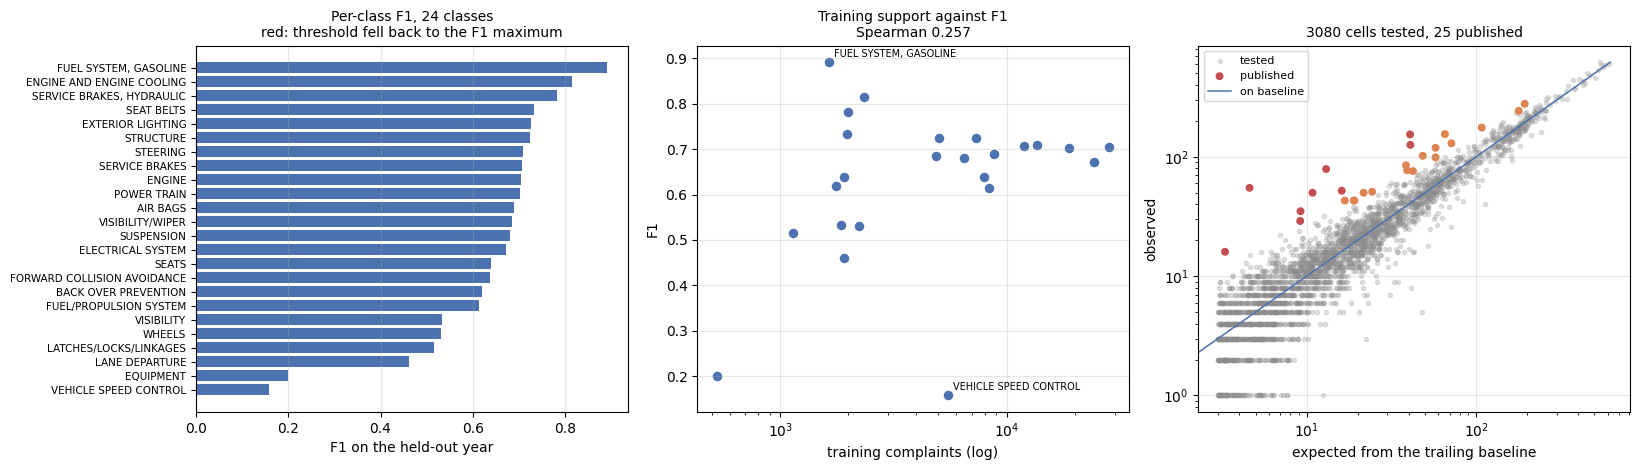

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))

ax = axes[0]
order = per_class.sort_values('f1')
y = np.arange(len(order))
colours = ['#C44E52' if b == 'fallback_f1' else '#4C72B0' for b in order['basis']]
ax.barh(y, order['f1'], color=colours)
ax.set_yticks(y)
ax.set_yticklabels([n[:29] for n in order['class']], fontsize=7.5)
ax.set_xlabel('F1 on the held-out year')
ax.set_title('Per-class F1, %d classes\nred: threshold fell back to the F1 maximum'
             % len(CLASSES), fontsize=10)
ax.grid(axis='x', alpha=0.3)

ax = axes[1]
ax.scatter(per_class['train'], per_class['f1'], s=34, color='#4C72B0')
ax.set_xscale('log')
ax.set_xlabel('training complaints (log)')
ax.set_ylabel('F1')
ax.set_title('Training support against F1\nSpearman %.3f' % corr, fontsize=10)
ax.grid(alpha=0.3)
for _, r in per_class.iloc[[0, -1]].iterrows():
    ax.annotate(r['class'][:22], (r['train'], r['f1']), fontsize=7,
                xytext=(4, 4), textcoords='offset points')

ax = axes[2]
test_cells = trend[trend['source'] == 'test']
ax.scatter(test_cells['expected'], test_cells['observed'], s=9, alpha=0.25,
           color='#8C8C8C', label='tested')
ax.scatter(published['expected'], published['observed'], s=22,
           color=['#C44E52' if p == 'P2' else '#DD8452' for p in published['priority']],
           label='published')
lim = max(test_cells['expected'].max(), test_cells['observed'].max())
ax.plot([0, lim], [0, lim], color='#4C72B0', linewidth=1.1, label='on baseline')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('expected from the trailing baseline')
ax.set_ylabel('observed')
ax.set_title('%d cells tested, %d published' % (len(test_cells), len(published)), fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
save_figure(fig, 'nhtsa_model_overview', subfolder='nlp')
plt.show()

## 15. Write the artifacts

In [26]:
import joblib

model_path = CKPT / f'{MODEL_VERSION}.joblib'
joblib.dump({'vectoriser': vectoriser, 'model': model, 'classes': CLASSES,
             'thresholds': THRESH}, model_path)
print(f'wrote {model_path.relative_to(REPO_ROOT).as_posix()}  '
      f'{model_path.stat().st_size / 1e6:.1f} MB')

meta = {
    'model_version': MODEL_VERSION,
    'created': time.strftime('%Y-%m-%d'),
    'seed': SEED,
    'python': platform.python_version(),
    'dataset': {
        'name': 'NHTSA consumer complaints 2020-2024',
        'complaints': int(len(df)),
        'classes': CLASSES,
        'cutover': space['cutover'],
        'splits': {k: int(len(v)) for k, v in parts.items()},
        'split_windows': {k: [v['datea'].min(), v['datea'].max()] for k, v in parts.items()},
        'mean_labels_per_complaint': float(df['label_list'].str.len().mean()),
    },
    'features': {
        'vectoriser': 'TfidfVectorizer',
        'ngram_range': [1, 2],
        'min_df': 5,
        'sublinear_tf': True,
        'vocabulary': int(len(vectoriser.vocabulary_)),
    },
    'classifier': {
        'estimator': 'OneVsRestClassifier(LogisticRegression, liblinear, C=1.0)',
        'fit_seconds': round(fit_seconds, 1),
    },
    'performance': {
        'test': tuned,
        'test_at_default_threshold': default,
        'baseline_constant': baseline_const,
        'baseline_prevalence': baseline_prior,
        'ablation_unigrams_only': uni,
        'ablation_unigram_vocabulary': int(len(uni_vec.vocabulary_)),
        'refit': repeat_report,
        'refit_max_probability_delta': max_prob_delta,
        'per_class': per_class.to_dict(orient='records'),
        'support_f1_spearman': float(corr),
    },
    'operating_point': {
        'class_thresholds': {c: float(thresholds[c]) for c in CLASSES},
        'class_threshold_basis': basis,
        'target_precision': TARGET_PRECISION,
        'classes_on_fallback': n_fallback,
        'band_edge': float(BAND_EDGE),
        'band_basis': BAND_BASIS,
        'band_rule': (f'lowest risk score at which a model-flagged cell is also flagged '
                      f'from the labels at least {TARGET_AGREEMENT:.0%} of the time, on '
                      f'the calibration months'),
        'target_agreement': TARGET_AGREEMENT,
        'min_calibration_cells': MIN_CALIBRATION_CELLS,
        'calibration_cells_available': int(len(calib)),
        'band_score_agreement_spearman': float(rank_corr),
        'band_probe': band_probe,
    },
    'trend': {
        'cell': 'manufacturer x component x month',
        'baseline': f'trailing {BASELINE_MONTHS} months, minimum {MIN_BASELINE_MONTHS}',
        'baseline_source': 'model predictions on months the model was not fitted on',
        'min_expected': MIN_EXPECTED,
        'family_alpha': FAMILY_ALPHA,
        'corrected_alpha': float(ALPHA),
        'cells_tested': int(n_tested),
        'cells_published': int(len(published)),
        'label_reference_flagged': int(len(truth_test_flags)),
        'agreement_precision': float(trend_precision),
        'agreement_recall': float(trend_recall),
        'priority_counts': {k: int(v) for k, v in published['priority'].value_counts().items()},
        'manufacturer_month_groups': int(len(clusters)),
        'events_sharing_a_group': int(in_clusters),
        'largest_group': int(largest),
        'events_from_repeating_pairs': int(repeated),
    },
}
meta_path = CKPT / 'nhtsa_nlp_meta.json'
meta_path.write_text(json.dumps(meta, indent=2), encoding='utf-8')
print(f'wrote {meta_path.relative_to(REPO_ROOT).as_posix()}')

wrote models/checkpoints/nhtsa/nhtsa_tfidf_ovr_v1.joblib  44.1 MB
wrote models/checkpoints/nhtsa/nhtsa_nlp_meta.json


In [27]:
# The table the event adapter reads. Every field it needs is here, so the adapter reads
# one file and computes nothing that this notebook already decided.
cells_out = []
for r in published.itertuples():
    cells_out.append({
        'manufacturer': r.mfr_name,
        'component': r.component,
        'month': r.month,
        'observed': int(r.observed),
        'expected': round(float(r.expected), 3),
        'ratio': round(float(r.ratio), 4),
        'risk_score': round(float(r.risk_score), 4),
        'p_value': float(r.p_value),
        'month_complaints': int(r.month_complaints),
        'baseline_flagged': int(r.baseline_flagged),
        'baseline_complaints': int(r.baseline_complaints),
        'baseline_months': int(r.baseline_months),
        'label_reference_agrees': bool(r.agrees),
    })
pred_path = PROCESSED / 'test_nhtsa_trend_cells.json'
pred_path.write_text(json.dumps({
    'model_version': MODEL_VERSION,
    'band_edge': float(BAND_EDGE),
    'band_basis': BAND_BASIS,
    'corrected_alpha': float(ALPHA),
    'family_alpha': FAMILY_ALPHA,
    'min_expected': MIN_EXPECTED,
    'cells_tested': int(n_tested),
    'cells': cells_out,
}, indent=1), encoding='utf-8')
print(f'wrote {pred_path.relative_to(REPO_ROOT).as_posix()}  {len(cells_out):,} cells')

wrote data/07_nhtsa_complaints/processed/test_nhtsa_trend_cells.json  25 cells


## 16. Log the run

In [28]:
import mlflow

mlflow.set_tracking_uri(get_mlflow_uri())
mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name=MODEL_VERSION):
    mlflow.set_tags({'dataset': 'nhtsa_complaints_2020_2024', 'task': 'multilabel_text',
                     'framework': 'scikit-learn', 'architecture': 'tfidf_ovr_logistic',
                     'num_classes': str(len(CLASSES)), 'department': 'Field Quality',
                     'business_domain': 'field_quality'})
    mlflow.log_params({'ngram_range': '1-2', 'min_df': 5, 'C': 1.0, 'seed': SEED,
                       'vocabulary': len(vectoriser.vocabulary_),
                       'target_precision': TARGET_PRECISION,
                       'family_alpha': FAMILY_ALPHA, 'min_expected': MIN_EXPECTED,
                       'baseline_months': BASELINE_MONTHS,
                       'band_basis': BAND_BASIS})
    mlflow.log_metrics({'test_micro_f1': tuned['micro_f1'],
                        'test_macro_f1': tuned['macro_f1'],
                        'test_micro_precision': tuned['micro_precision'],
                        'test_micro_recall': tuned['micro_recall'],
                        'test_exact_set': tuned['exact_set'],
                        'default_threshold_micro_f1': default['micro_f1'],
                        'unigram_micro_f1': uni['micro_f1'],
                        'refit_micro_f1': repeat_report['micro_f1'],
                        'band_edge': float(BAND_EDGE),
                        'trend_precision': trend_precision,
                        'trend_recall': trend_recall,
                        'cells_published': float(len(published))})
    mlflow.log_artifact(str(meta_path))
    print(f'logged run {mlflow.active_run().info.run_id} to experiment {EXPERIMENT_NAME}')

logged run 43846556a16247e19b496e229a0ba6af to experiment arkon_nhtsa_nlp


## 17. Results

In [29]:
print(f'1. Micro F1 {tuned["micro_f1"]:.4f} and macro F1 {tuned["macro_f1"]:.4f} on '
      f'{len(parts["test"]):,} complaints')
print(f'   received in 2024, over {len(CLASSES)} component classes, from the narrative text')
print(f'   alone. The always-{CLASSES[most_common]} reference scores '
      f'{baseline_const["micro_f1"]:.4f}.')
print(f'   {tuned["any_label_hit"]:.1%} of complaints get at least one of their components right;')
print(f'   {tuned["exact_set"]:.1%} get the exact set, which is the harsh reading and the')
print('   honest one for a multi-label task.')
print()
print(f'2. Per-class F1 runs from {per_class["f1"].min():.3f} to {per_class["f1"].max():.3f}. '
      f'Spearman correlation with')
print(f'   training support is {corr:.3f}.')
print()
print(f'3. {len(CLASSES) - n_fallback} of {len(CLASSES)} classes reached the '
      f'{TARGET_PRECISION:.0%} precision target on the')
print(f'   selection split; {n_fallback} fell back to their F1 maximum and every event says so.')
print()
print(f'4. It reproduces exactly. A refit at the same seed moved no probability by more')
print(f'   than {max_prob_delta:.1e}, which is the first Arkon module of which that is true.')
print()
print(f'5. Bigrams are worth {tuned["micro_f1"] - uni["micro_f1"]:+.4f} micro F1 for '
      f'{len(vectoriser.vocabulary_) - len(uni_vec.vocabulary_):,} extra features.')
print()
print(f'6. The trend detector tested {n_tested:,} manufacturer-component-month cells in')
print(f'   2024 and published {len(published):,} at a Bonferroni-corrected alpha of {ALPHA:.2e}.')
print(f'   Against the identical procedure run on the true labels: precision '
      f'{trend_precision:.3f},')
print(f'   recall {trend_recall:.3f}.')
print()
print(f'7. The band edge is declared at {BAND_EDGE:.2f}, not calibrated, and this is the third')
print(f'   module whose declared band rule failed to return an answer. It could not be')
print(f'   asked here: it needs {MIN_CALIBRATION_CELLS} flagged calibration cells and there are {len(calib)}.')
print()
print(f'8. Size of movement does not predict truth. Spearman correlation between the')
print(f'   risk score and agreement with the labels is {rank_corr:.3f}, and above a 0.80 edge')
print(f'   the ordering inverts. The priority says how big, never how certain.')
print()
print(f'9. The events are not independent. {in_clusters} of {len(published)} share a manufacturer')
print(f'   and a month with another event, the largest group holding {largest}, and')
print(f'   {repeated} come from pairs that fired in more than one month.')

1. Micro F1 0.6867 and macro F1 0.6306 on 60,039 complaints
   received in 2024, over 24 component classes, from the narrative text
   alone. The always-ENGINE reference scores 0.1982.
   92.6% of complaints get at least one of their components right;
   40.8% get the exact set, which is the harsh reading and the
   honest one for a multi-label task.

2. Per-class F1 runs from 0.157 to 0.892. Spearman correlation with
   training support is 0.257.

3. 24 of 24 classes reached the 60% precision target on the
   selection split; 0 fell back to their F1 maximum and every event says so.

4. It reproduces exactly. A refit at the same seed moved no probability by more
   than 0.0e+00, which is the first Arkon module of which that is true.

5. Bigrams are worth +0.0019 micro F1 for 184,015 extra features.

6. The trend detector tested 3,080 manufacturer-component-month cells in
   2024 and published 25 at a Bonferroni-corrected alpha of 3.25e-06.
   Against the identical procedure run on the 